I denna labben har jag testat en förtränad CNN-modell (Resnet18) och undersökt hur den analyserar bilder med hjälp av en heatmap. 
Genom denna heatmapen kan man se vilken del av bilden modellen kollar på när den tar sina beslut

In [1]:
import matplotlib.pyplot as plt
import torch

from torchvision.transforms.v2.functional import to_pil_image
from torchvision.models import get_model, get_model_weights
from torchvision.io import decode_image

from torchcam.utils import overlay_mask
from torchcam.methods import LayerCAM

from pathlib import Path

Modellen som valts under detta programet är "Resnet18" som har varit passande vid detta tillfället då det är en vältränad modell som funkar bra när man inte har tillgång till superbra hårdvara

In [2]:
images_dir = Path(r"C:\Users\frolu\OneDrive\Skrivbord\skol kodning\Book")

weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

preprocess = weights.transforms()

cam_extractor = LayerCAM(model, target_layer="layer4")

Bilderna som valts att använda va av en chimpans, Lemur, Nebbdjur, Svärds-haj, Barr-träd och en palm som inte blev som tänkt som man kommer se senare i programmet

In [3]:

picturs = [
    "chimpans.png",
    "Lemur.png",
    "nebbdjur.png",
    "sverd_haj.png",
    "Barr_tred.png",
    "palm.png"

]

idx_to_label = weights.meta["categories"]

for pic in picturs:
    img = decode_image(pic)
    input_tensor = preprocess(img).unsqueeze(0)

    out = model(input_tensor)

    probs = torch.softmax(out, dim=1)
    top_probs, top_idxs = probs.topk(5, dim=1)

    print(f"\nBild: {pic}")

    for i in range(5):
        idx = top_idxs[0, i].item()
        prob = top_probs[0, i].item()
        name = idx_to_label[idx]

        print(f"{i+1}. {name} ({prob:.3f})")


Bild: chimpans.png
1. chimpanzee (0.998)
2. spider monkey (0.001)
3. langur (0.001)
4. siamang (0.000)
5. macaque (0.000)

Bild: Lemur.png
1. Madagascar cat (0.950)
2. indri (0.050)
3. koala (0.000)
4. gibbon (0.000)
5. mongoose (0.000)

Bild: nebbdjur.png
1. platypus (1.000)
2. otter (0.000)
3. beaver (0.000)
4. mink (0.000)
5. brown bear (0.000)

Bild: sverd_haj.png
1. hammerhead (0.683)
2. tiger shark (0.210)
3. great white shark (0.098)
4. gar (0.003)
5. killer whale (0.002)

Bild: Barr_tred.png
1. worm fence (0.147)
2. lakeside (0.101)
3. maze (0.039)
4. bison (0.036)
5. mountain bike (0.031)

Bild: palm.png
1. seashore (0.800)
2. sandbar (0.093)
3. sea urchin (0.027)
4. tarantula (0.013)
5. lakeside (0.010)


Här över kan man tydligt se hur modellen resonerar när den väljer vad som finns på bilden

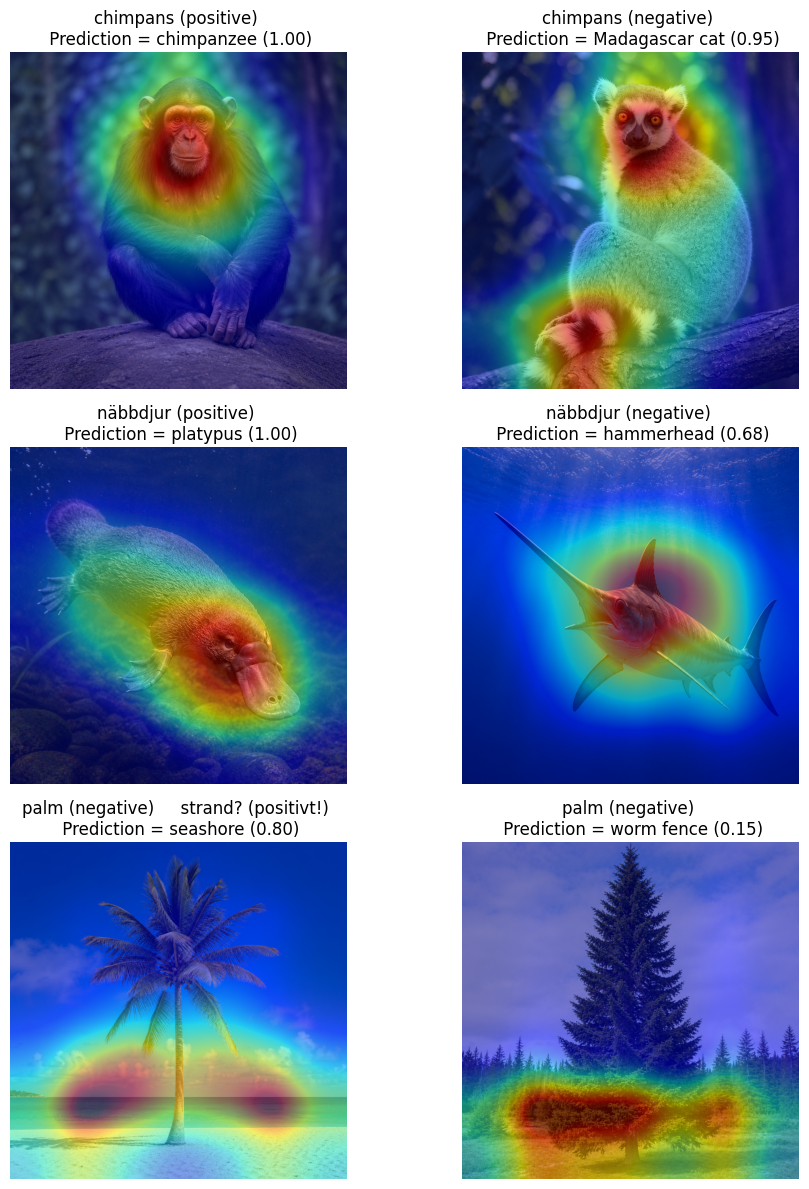

In [4]:
picturs = [
    ("chimpans.png", "chimpans", "positive"),
    ("Lemur.png", "chimpans", "negative"),

    ("nebbdjur.png", "näbbdjur", "positive"),
    ("sverd_haj.png", "näbbdjur", "negative"),

    ("palm.png", "palm", "negative)     strand? (positivt!"),
    ("Barr_tred.png", "palm", "negative"),
]

idex_to_label = weights.meta["categories"]

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

for ax, (file, name, label_type) in zip(axes, picturs):
    img = decode_image(file)
    
    out = model(preprocess(img).unsqueeze(0))

    probability = torch.softmax(out, dim=1)
    predictions_index = probability.argmax(dim=1).item()
    predictions_name = idex_to_label[predictions_index]
    confidence = probability[0, predictions_index].item()

    activation_map = cam_extractor(predictions_index, out)

    result = overlay_mask(
        to_pil_image(img),
        to_pil_image(activation_map[0].squeeze(0), mode='F'),
        alpha=0.5
    )

    ax.imshow(result)
    ax.set_title(f"{name} ({label_type}) \n Prediction = {predictions_name} ({confidence:.2f})")
    ax.axis("off")

plt.tight_layout()
plt.show()

Resultaten visar att modellen i många fall identifirar rätt objekt i de positiva bilderna.
Med hjälp av heatmapen ser man också att modellen oftast fokuserar på relevanta delar av bilden när den tar sina beslut.
Samtidigt märker man väldigt snabbt att modellen inte alltid har rätt. Det förekommer ett tydligt exempel ganska snabbt här att den tror att Lemuren är en "katt" och är 0,95 procent säker. 
En människa hade dock kunnat identifiera bilden väldigt snabbt och vetat vad vi kollar på och då kollar man på samma saker som modellen kollar på.
Detta visar att modellen inte går att lita på utan man ska vara kritisk och väldigt nogran när man använder tränade modeller.
